# Part 1: Data Preparation & Leakage-Free Pipeline
**Course:** CS-13410 Introduction to Machine Learning

**Dataset:** Heart Disease UCI (920 rows, 16 columns)

**Problem:** Predict whether a patient has heart disease (binary classification)

In [1]:
import pandas as pd
df = pd.read_csv("heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [2]:
df.shape

(920, 16)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
df.isna().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [5]:
(df.isna().sum() / len(df) * 100).round(1)

,0
id,0.0
age,0.0
sex,0.0
dataset,0.0
cp,0.0
trestbps,6.4
chol,3.3
fbs,9.8
restecg,0.2
thalch,6.0


In [6]:
df = df.drop(columns=["id", "ca"])
df.shape

(920, 14)

In [7]:
df["target"] = (df["num"] > 0).astype(int)
df["target"].value_counts()

,count
target,
1,509
0,411


## Problem Framing
- **Target variable:** `target` (derived from `num`: 0 = no disease, 1 = disease)
- **Task type:** Binary classification
- **Success metric:** F1-score and ROC-AUC (not accuracy alone, because missing a diseased patient is costly)
- **Columns dropped:** `id` (only a serial number) and `ca` (about 66% missing values)


In [8]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["num", "target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(736, 13) (184, 13)
target
1    0.552989
0    0.447011
Name: proportion, dtype: float64
target
1    0.554348
0    0.445652
Name: proportion, dtype: float64


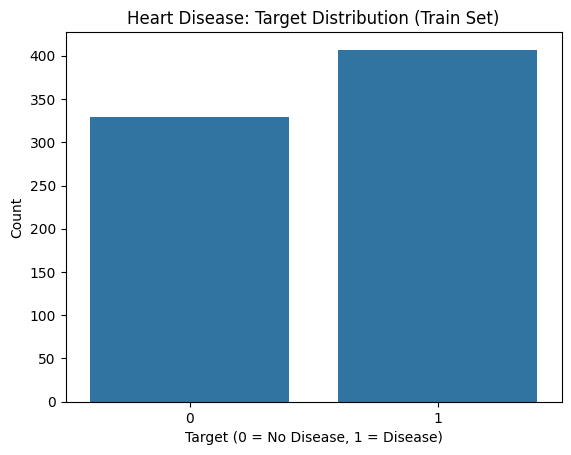

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

train = X_train.copy()
train["target"] = y_train

sns.countplot(x="target", data=train)
plt.title("Heart Disease: Target Distribution (Train Set)")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()

**Finding:** The two classes are fairly balanced (about 55% disease, 45% no disease), so class imbalance is not a serious problem here. Class imbalance was checked: classes are roughly balanced (55/45), so no resampling is needed.

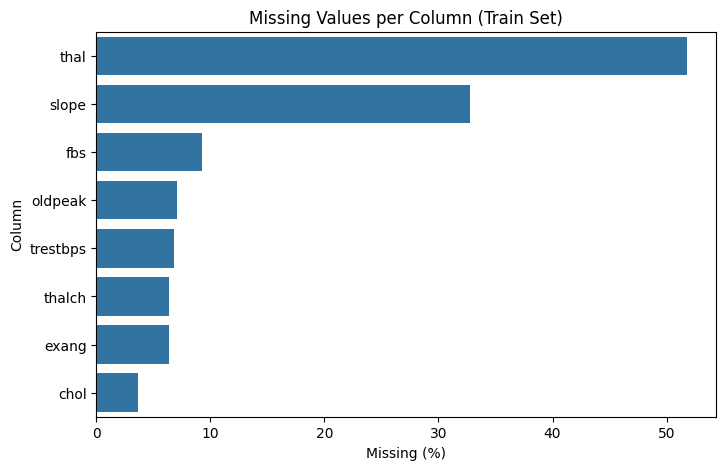

In [10]:
missing = (X_train.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(8, 5))
sns.barplot(x=missing.values, y=missing.index)
plt.title("Missing Values per Column (Train Set)")
plt.xlabel("Missing (%)")
plt.ylabel("Column")
plt.show()

**Finding:** `thal` (about 52%) and `slope` (about 33%) have the most missing values. The other columns have less than 10% missing. Missing values will be imputed inside the pipeline (median for numeric, most frequent for categorical) so that no information from the test set is used.

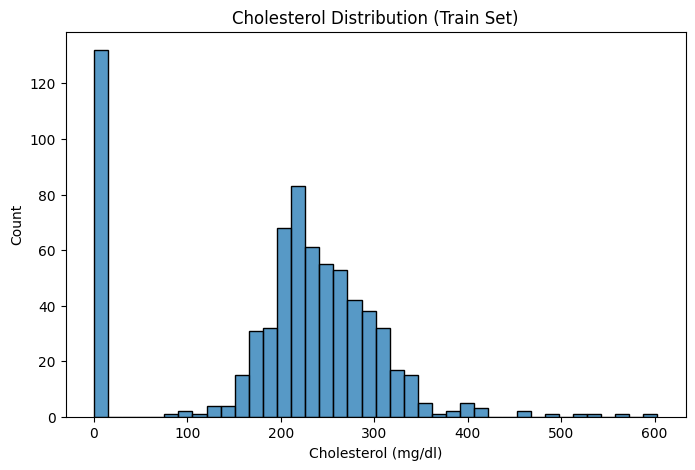

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(data=train, x="chol", bins=40)
plt.title("Cholesterol Distribution (Train Set)")
plt.xlabel("Cholesterol (mg/dl)")
plt.ylabel("Count")
plt.show()

In [12]:
import numpy as np

for data in [X_train, X_test]:
    data["chol"] = data["chol"].replace(0, np.nan)
    data["trestbps"] = data["trestbps"].replace(0, np.nan)

print((X_train[["chol", "trestbps"]].isna().mean() * 100).round(1))

chol        21.6
trestbps     6.8
dtype: float64


**Finding:** The cholesterol histogram shows a large spike at 0, which is medically impossible. These zeros are hidden missing values (recorded as 0 instead of blank). They were converted to NaN so they will be imputed inside the pipeline like other missing values. The same fix was applied to `trestbps` (blood pressure).

In [13]:
train = X_train.copy()
train["target"] = y_train

"After conversion, the distribution looks normal between about 100 and 600 mg/dl."

In [14]:
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Categorical: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
], sparse_threshold=0)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(X_train_prep.shape, X_test_prep.shape)
print("Missing after prep:", np.isnan(X_train_prep).sum())

(736, 28) (184, 28)
Missing after prep: 0
